# Assignment 3 - Jazil's Notebook

## FLAML AutoML Regression -


In [1]:
# Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from flaml.automl import AutoML
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')
np.random.seed(2024)

In [4]:
# Data loading
data_fp = "D:\\UCHICAGO\\UChicago Courses\\Machine Learning Operations\\athletes\\athletes.csv"  # Change path as needed
athlete_df = pd.read_csv(data_fp)
athlete_df.head()

,athlete_id,name,region,team,affiliate,gender,age,height,weight,fran,...,snatch,deadlift,backsq,pullups,eat,train,background,experience,schedule,howlong
0,2554.0,Pj Ablang,South West,Double Edge,Double Edge CrossFit,Male,24.0,70.0,166.0,NaN,...,NaN,400.0,305.0,NaN,NaN,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|I r...,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|
1,3517.0,Derek Abdella,NaN,NaN,NaN,Male,42.0,70.0,190.0,NaN,...,NaN,NaN,NaN,NaN,NaN,I have a coach who determines my programming|I...,I played youth or high school level sports|,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|
2,4691.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5164.0,Abo Brandon,Southern California,LAX CrossFit,LAX CrossFit,Male,40.0,67.0,NaN,211.0,...,200.0,375.0,325.0,25.0,I eat 1-3 full cheat meals per week|,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|,4+ years|
4,5286.0,Bryce Abbey,NaN,NaN,NaN,Male,32.0,65.0,149.0,206.0,...,150.0,NaN,325.0,50.0,I eat quality foods but don't measure the amount|,I workout mostly at a CrossFit Affiliate|I inc...,I played college sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|I strictly s...,1-2 years|


In [17]:
# Remove not relevant columns
athlete_df = athlete_df.dropna(subset=[
    'region', 'age', 'weight', 'height', 'howlong', 'gender', 'eat',
    'train', 'background', 'experience', 'schedule', 'howlong',
    'deadlift', 'candj', 'snatch', 'backsq'
])
athlete_df = athlete_df.drop(columns=[
    'affiliate', 'team', 'name', 'athlete_id', 'fran', 'helen', 'grace',
    'filthy50', 'fgonebad', 'run400', 'run5k', 'pullups', 'train'
])

# Remove Outliers
athlete_df = athlete_df[athlete_df['weight'] < 1500]
athlete_df = athlete_df[athlete_df['gender'] != '--']
athlete_df = athlete_df[athlete_df['age'] >= 18]
athlete_df = athlete_df[(athlete_df['height'] < 96) & (athlete_df['height'] > 48)]

athlete_df = athlete_df[
    ((athlete_df['gender'] == 'Male') & (athlete_df['deadlift'] > 0) & (athlete_df['deadlift'] <= 1105)) |
    ((athlete_df['gender'] == 'Female') & (athlete_df['deadlift'] > 0) & (athlete_df['deadlift'] <= 636))
]
athlete_df = athlete_df[(athlete_df['candj'] > 0) & (athlete_df['candj'] <= 395)]
athlete_df = athlete_df[(athlete_df['snatch'] > 0) & (athlete_df['snatch'] <= 496)]
athlete_df = athlete_df[(athlete_df['backsq'] > 0) & (athlete_df['backsq'] <= 1069)]

# Clean Survey Data
decline_dict = {'Decline to answer|': np.nan}
athlete_df = athlete_df.replace(decline_dict)
athlete_df = athlete_df.dropna(subset=['background', 'experience', 'schedule', 'howlong', 'eat'])


## Exploratory Data Analysis (EDA)
Let's look at the data structure, missing values, and some distributions.

In [18]:
print("Shape:", athlete_df.shape)
print("\nColumns:", athlete_df.columns.tolist())
print("\nMissing values:\n", athlete_df.isnull().sum())
athlete_df.describe()

Shape: (30015, 14)

Columns: ['region', 'gender', 'age', 'height', 'weight', 'candj', 'snatch', 'deadlift', 'backsq', 'eat', 'background', 'experience', 'schedule', 'howlong']

Missing values:
 region        0
gender        0
age           0
height        0
weight        0
candj         0
snatch        0
deadlift      0
backsq        0
eat           0
background    0
experience    0
schedule      0
howlong       0
dtype: int64


,age,height,weight,candj,snatch,deadlift,backsq
count,30015.000000,30015.000000,30015.000000,30015.000000,30015.000000,30015.000000,30015.000000
mean,32.125271,68.873397,177.146660,205.427520,156.178011,362.102815,294.141596
std,7.436255,3.774809,32.397735,58.696774,48.841798,96.451618,85.090633
min,18.000000,52.000000,5.000000,1.000000,1.000000,1.000000,1.000000
25%,27.000000,66.000000,155.000000,160.000000,120.000000,287.000000,225.000000
50%,31.000000,69.000000,178.000000,205.000000,155.000000,375.000000,300.000000
75%,37.000000,72.000000,197.000000,245.000000,190.000000,435.000000,355.000000
max,56.000000,83.000000,474.000000,390.000000,386.000000,1000.000000,882.000000


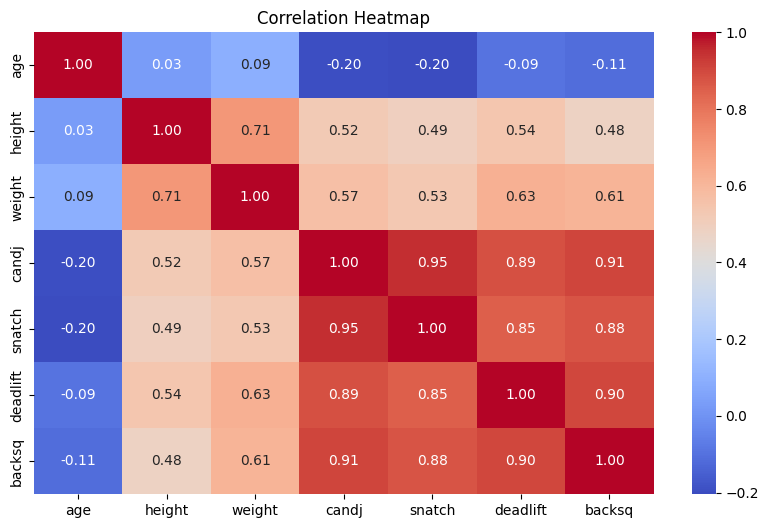

In [19]:
# Correlation heatmap for numeric features
plt.figure(figsize=(10, 6))
sns.heatmap(athlete_df.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

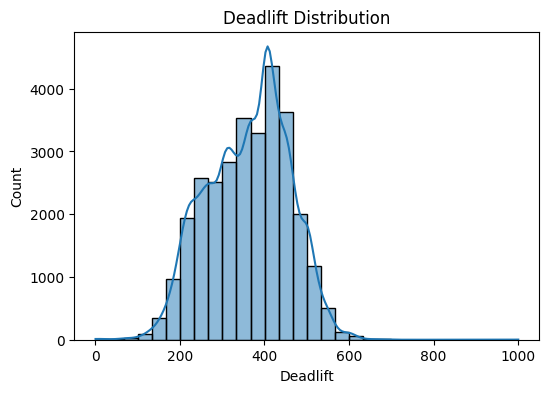

In [20]:
# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.histplot(athlete_df["deadlift"].dropna(), bins=30, kde=True)
plt.title("Deadlift Distribution")
plt.xlabel("Deadlift")
plt.show()

## Data Preprocessing
We'll drop irrelevant columns, handle missing values, and encode categoricals.

In [21]:
df2 = athlete_df.copy()


# Handle missing values
for col in df2.select_dtypes(include=[np.number]).columns:
    df2[col] = df2[col].fillna(df2[col].mean())
for col in df2.select_dtypes(include="object").columns:
    df2[col] = df2[col].fillna("Unknown").astype("category").cat.codes

# Feature/target split
target_col = "deadlift"
features = df2.drop(columns=[target_col])
target = df2[target_col]

In [22]:
# Baseline model: mean predictor
mean_pred = np.full_like(target, target.mean())
baseline_rmse = np.sqrt(mean_squared_error(target, mean_pred))
print(f"Baseline RMSE (mean predictor): {baseline_rmse:.2f}")

Baseline RMSE (mean predictor): 96.45


In [23]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=2024)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (24012, 13) Test shape: (6003, 13)


## FLAML AutoML - All Features
Let's run FLAML on all features and evaluate the results.

In [24]:
flaml_full = AutoML()
flaml_settings = {
    "time_budget": 60,
    "metric": "rmse",
    "task": "regression",
    "log_file_name": "flaml_full.log"
}
import time
start_time = time.time()
flaml_full.fit(X_train=X_train, y_train=y_train, **flaml_settings)
full_time = time.time() - start_time

y_pred_full = flaml_full.predict(X_test)
rmse_full = np.sqrt(mean_squared_error(y_test, y_pred_full))
print(f"All-features RMSE: {rmse_full:.2f}")
print("Best model (all features):", flaml_full.best_estimator)
print("Best validation loss:", flaml_full.best_loss)
print(f"Elapsed time: {full_time:.1f} s")

[flaml.automl.logger: 07-23 21:40:19] {1752} INFO - task = regression
[flaml.automl.logger: 07-23 21:40:19] {1763} INFO - Evaluation method: holdout


[flaml.automl.logger: 07-23 21:40:19] {1862} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 07-23 21:40:19] {1979} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd']
[flaml.automl.logger: 07-23 21:40:19] {2282} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 07-23 21:40:19] {2417} INFO - Estimated sufficient time budget=1234s. Estimated necessary time budget=9s.
[flaml.automl.logger: 07-23 21:40:19] {2466} INFO -  at 0.2s,	estimator lgbm's best error=71.9060,	best estimator lgbm's best error=71.9060
[flaml.automl.logger: 07-23 21:40:19] {2282} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 07-23 21:40:20] {2466} INFO -  at 0.4s,	estimator lgbm's best error=71.9060,	best estimator lgbm's best error=71.9060
[flaml.automl.logger: 07-23 21:40:20] {2282} INFO - iteration 2, current learner sgd
[flaml.automl.logger: 07-23 21:40:23] {2466} INFO -  at 3.4s,	estimator sgd's best error=75.8339,	bes

Top 5 Features:
 weight    382
backsq    373
candj     326
snatch    275
age       215
dtype: int32


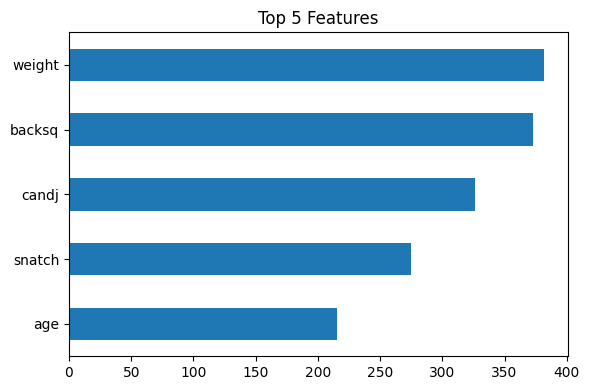

In [25]:
# Feature importance (top 5)
if hasattr(flaml_full.model.estimator, 'feature_importances_'):
    importances = pd.Series(flaml_full.model.estimator.feature_importances_, index=X_train.columns)
    top5_feats = importances.sort_values(ascending=False).head(5)
    print("Top 5 Features:\n", top5_feats)
    top5_feats.plot(kind="barh", title="Top 5 Features", figsize=(6, 4))
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances not available for this estimator.")

## FLAML AutoML - Top 3 Features Only
Now let's run FLAML using only the top 3 features.

In [26]:
top3_names = top5_feats.index[:3]
X_train_top3 = X_train[top3_names]
X_test_top3 = X_test[top3_names]

flaml_top3 = AutoML()
settings_top3 = {
    "time_budget": 60,
    "metric": "rmse",
    "task": "regression",
    "log_file_name": "flaml_top3.log"
}
t0 = time.time()
flaml_top3.fit(X_train=X_train_top3, y_train=y_train, **settings_top3)
t_top3 = time.time() - t0

y_pred_top3 = flaml_top3.predict(X_test_top3)
rmse_top3 = np.sqrt(mean_squared_error(y_test, y_pred_top3))
print(f"Top-3-features RMSE: {rmse_top3:.2f}")
print("Best model (top 3):", flaml_top3.best_estimator)
print("Best validation loss (top 3):", flaml_top3.best_loss)
print(f"Elapsed time: {t_top3:.1f} s")

[flaml.automl.logger: 07-23 21:42:18] {1752} INFO - task = regression
[flaml.automl.logger: 07-23 21:42:18] {1763} INFO - Evaluation method: cv
[flaml.automl.logger: 07-23 21:42:18] {1862} INFO - Minimizing error metric: rmse


[flaml.automl.logger: 07-23 21:42:18] {1979} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd']
[flaml.automl.logger: 07-23 21:42:18] {2282} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 07-23 21:42:19] {2417} INFO - Estimated sufficient time budget=2873s. Estimated necessary time budget=21s.
[flaml.automl.logger: 07-23 21:42:19] {2466} INFO -  at 0.3s,	estimator lgbm's best error=72.2083,	best estimator lgbm's best error=72.2083
[flaml.automl.logger: 07-23 21:42:19] {2282} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 07-23 21:42:19] {2466} INFO -  at 0.6s,	estimator lgbm's best error=72.2083,	best estimator lgbm's best error=72.2083
[flaml.automl.logger: 07-23 21:42:19] {2282} INFO - iteration 2, current learner sgd
[flaml.automl.logger: 07-23 21:42:25] {2466} INFO -  at 6.6s,	estimator sgd's best error=86.5038,	best estimator lgbm's best error=72.2083
[flaml.automl.logger: 07-23 21:42:25] {2282

## Results Comparison
Let's compare the baseline, all-features, and top-3-features models.

In [27]:
results = pd.DataFrame({
    "Model": ["Baseline (mean)", "FLAML (all features)", "FLAML (top 3 features)"],
    "RMSE": [baseline_rmse, rmse_full, rmse_top3]
})
print(results)

                    Model       RMSE
0         Baseline (mean)  96.450012
1    FLAML (all features)  36.040397
2  FLAML (top 3 features)  36.508095


In [28]:
# Show best model configurations
print("Best configs (all features):")
print(flaml_full.best_config_per_estimator)
print("\nBest configs (top 3 features):")
print(flaml_top3.best_config_per_estimator)

Best configs (all features):
{'lgbm': {'n_estimators': 158, 'num_leaves': 18, 'min_child_samples': 3, 'learning_rate': np.float64(0.17402065726724145), 'log_max_bin': 8, 'colsample_bytree': np.float64(0.6649148062238498), 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(0.006761362450996487)}, 'rf': {'n_estimators': 6, 'max_features': np.float64(0.7754448469593765), 'max_leaves': 168}, 'xgboost': {'n_estimators': 64, 'max_leaves': 12, 'min_child_weight': np.float64(51.84874392377363), 'learning_rate': np.float64(0.1115271479445595), 'subsample': 1.0, 'colsample_bylevel': np.float64(0.8182737361783602), 'colsample_bytree': np.float64(0.8031986460435498), 'reg_alpha': np.float64(0.00400039941928546), 'reg_lambda': np.float64(0.3870252968100477)}, 'extra_tree': {'n_estimators': 6, 'max_features': np.float64(0.7552682732533821), 'max_leaves': 533}, 'xgb_limitdepth': {'n_estimators': 10, 'max_depth': 7, 'min_child_weight': np.float64(1.4414106781003007), 'learning_rate': np.float64(0.365

# H2O AutoML Regression - Enhanced & Original Workflow

Now let's use H2O's AutoML to solve the same regression problem, with extra steps and new variable names for clarity.

In [30]:
# H2O imports and initialization
import h2o
from h2o.automl import H2OAutoML
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Start or connect to H2O server
h2o.init(max_mem_size="2G", nthreads=2)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 25.421-b09, mixed mode)
  Starting server from D:\UCHICAGO\UChicago Courses\Machine Learning Operations\Assignment3\mlops_env\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\afiniti\AppData\Local\Temp\tmpih8yv6q3
  JVM stdout: C:\Users\afiniti\AppData\Local\Temp\tmpih8yv6q3\h2o_afiniti_started_from_python.out
  JVM stderr: C:\Users\afiniti\AppData\Local\Temp\tmpih8yv6q3\h2o_afiniti_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,America/Chicago
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,3 months and 26 days
H2O_cluster_name:,H2O_from_python_afiniti_vrywoa
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.760 Gb
H2O_cluster_total_cores:,0
H2O_cluster_allowed_cores:,0
H2O_cluster_status:,"locked, healthy"


In [34]:
# Prepare data for H2O
# We'll use the same processed DataFrame as before (df2, features, target)
h2o_data = features.copy()
h2o_data["target_deadlift"] = target

# Split into train/test for H2O
h2o_train = h2o_data.loc[X_train.index].copy()
h2o_test = h2o_data.loc[X_test.index].copy()
# Convert to H2OFrame
hf_train = h2o.H2OFrame(h2o_train)
hf_test = h2o.H2OFrame(h2o_test)

h2o_features = [col for col in hf_train.columns if col != "target_deadlift"]
h2o_target = "target_deadlift"

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


## H2O AutoML - All Features

Let's run H2O's AutoML on all features and evaluate the results.

In [36]:
h2o_automl_full = H2OAutoML(max_runtime_secs=60, seed=2024, sort_metric="RMSE", verbosity="info")
import time
start_h2o = time.time()
h2o_automl_full.train(x=h2o_features, y=h2o_target, training_frame=hf_train)
elapsed_h2o = time.time() - start_h2o

# Predict and evaluate
pred_full = h2o_automl_full.leader.predict(hf_test).as_data_frame().values.flatten()
rmse_h2o_full = np.sqrt(mean_squared_error(h2o_test[h2o_target], pred_full))
print(f"H2O AutoML (all features) RMSE: {rmse_h2o_full:.2f}")
print("Best H2O model (all features):", h2o_automl_full.leader.model_id)
print(f"Elapsed time: {elapsed_h2o:.1f} s")

AutoML progress: |


22:00:24.580: Project: AutoML_2_20250723_220024
22:00:24.580: Blending will be used.
22:00:24.581: Setting stopping tolerance adaptively based on the training frame: 0.006453359105519719
22:00:24.581: Build control seed: 2024
22:00:24.581: Since cross-validation is disabled, and validation, blending frame(s) were not provided, automatically split the training data into training, validation, blending frame(s) in the ratio 70/10/20.
22:00:24.639: training frame: Frame key: AutoML_2_20250723_220024_training_Key_Frame__upload_9de7ac8a3b06a25c9feae4567af34348.hex    cols: 14    rows: 16810  chunks: 1    size: 305636  checksum: 5336231503851754440
22:00:24.640: validation frame: Frame key: AutoML_2_20250723_220024_validation_Key_Frame__upload_9de7ac8a3b06a25c9feae4567af34348.hex    cols: 14    rows: 2342  chunks: 1    size: 43403  checksum: 5336257440779424104
22:00:24.640: leaderboard frame: Frame key: AutoML_2_20250723_220024_validation_Key_Frame__upload_9de7ac8a3b06a25c9feae4567af34348.h

d:\UCHICAGO\UChicago Courses\Machine Learning Operations\Assignment3\mlops_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [37]:
# Feature importance for H2O (if available)
try:
    varimp = h2o_automl_full.leader.varimp(use_pandas=True)
    print("Top 5 H2O Features:\n", varimp.head())
    plt.figure(figsize=(7, 4))
    plt.barh(varimp["variable"][:5][::-1], varimp["relative_importance"][:5][::-1])
    plt.title("H2O - Top 5 Feature Importances")
    plt.xlabel("Relative Importance")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Feature importance not available for this model:", e)

Feature importance not available for this model: 'NoneType' object has no attribute 'head'


## FLAML vs H2O AutoML: Performance Comparison

Let's compare the RMSE and best model types from both AutoML frameworks.

In [38]:
# Example: Collect results (update variable names if yours are different)
comparison_df = pd.DataFrame({
    "Framework": ["FLAML (all features)", "H2O (all features)"],
    "Best Model": [flaml_full.best_estimator, h2o_automl_full.leader.model_id],
    "RMSE": [rmse_full, rmse_h2o_full],
    "Time (s)": [full_time, elapsed_h2o]
})

print(comparison_df)

              Framework                                         Best Model  \
0  FLAML (all features)                                               lgbm   
1    H2O (all features)  StackedEnsemble_BestOfFamily_4_AutoML_2_202507...   

        RMSE   Time (s)  
0  36.040397  61.681609  
1  35.632505  61.021535  


### Observations

- **FLAML** and **H2O** both provide strong AutoML solutions for regression.
- H20 is slightly better in terms of RMSE and time to run
- we need to decide on deployment and interpretibility. The best model type chosen by each (e.g., FLAML picked lgm, H2O picked a stacked ensemble are pretty different


They are very low code. H20 has a UI as well for completely low code running locally